In [1]:
#import e overview

# main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set
sns.set(style='whitegrid', palette='Set2', font_scale=1.1)

# read file CSV
df = pd.read_csv('ecommerce_customer_behavior_5000.csv')
df.info()
df.head()


/Users/lorenzafuria/opt/anaconda3/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            5000 non-null   int64  
 1   customer_age        5000 non-null   int64  
 2   customer_gender     5000 non-null   object 
 3   product_category    5000 non-null   object 
 4   payment_method      5000 non-null   object 
 5   order_value_usd     5000 non-null   float64
 6   delivery_time_days  5000 non-null   int64  
 7   customer_rating     5000 non-null   float64
 8   returned            5000 non-null   object 
 9   order_date          5000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 390.8+ KB


,order_id,customer_age,customer_gender,product_category,payment_method,order_value_usd,delivery_time_days,customer_rating,returned,order_date
0,1,37,Other,Home & Living,Wallet,1366.60,10,2.3,No,2022-01-01
1,2,41,Female,Fashion,Cash on Delivery,1175.89,6,1.8,Yes,2022-01-02
2,3,30,Other,Sports,Debit Card,1283.97,7,3.2,No,2022-01-03
3,4,58,Female,Electronics,Credit Card,1245.76,14,3.8,No,2022-01-04
4,5,59,Other,Fashion,Cash on Delivery,1411.06,7,3.2,No,2022-01-05


In [2]:
#check missing value and outliers

df.isnull().sum()

# handle date and variables
df['order_date'] = pd.to_datetime(df['order_date'])
#replace column "returned" from "Yes"/"No" to 1/0
df['returned'] = df['returned'].replace({'Yes': 1, 'No': 0}).astype(int)

# fillna or outlier trimming
df = df[df['order_value_usd'] < df['order_value_usd'].quantile(0.99)]


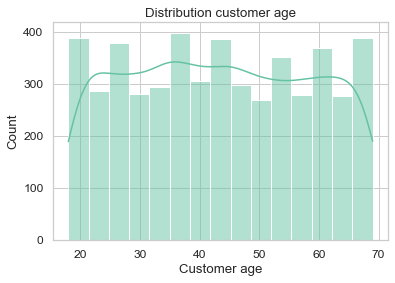

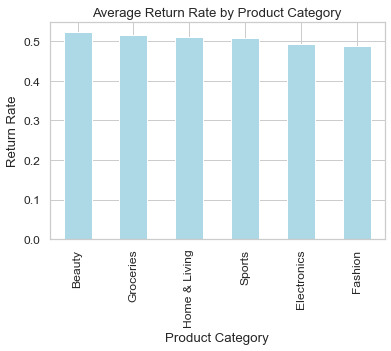

In [3]:
#distributions, correlation and main patterns

# distribution customer age
sns.histplot(df['customer_age'], bins=15, kde=True)
plt.title('Distribution customer age')
plt.xlabel('Customer age')
plt.show()

# average return rate by product category
returns = df.groupby('product_category')['returned'].mean().sort_values(ascending=False)
returns.plot(kind='bar', color='lightblue')
plt.title('Average Return Rate by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Return Rate')
plt.show()

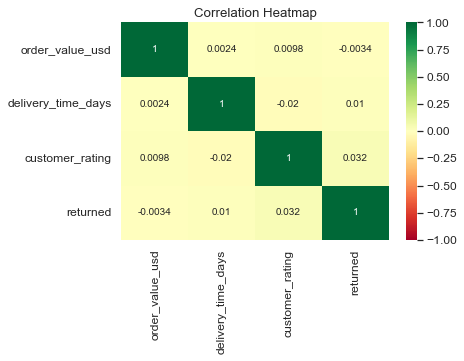

In [4]:
#correlations and insight

numeric_cols = ['order_value_usd', 'delivery_time_days', 'customer_rating', 'returned']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='RdYlGn', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [5]:
# Total number of orders
order_counts = df.groupby(['product_category', 'customer_gender'])['order_id'].count().unstack()

# Total number of returns
return_counts = df[df['returned'] == 1].groupby(['product_category', 'customer_gender'])['order_id'].count().unstack()

# Replace NaN with 0
return_counts = return_counts.fillna(0)

# Return percentage (returns / orders)
return_percentage = (return_counts / order_counts).fillna(0)

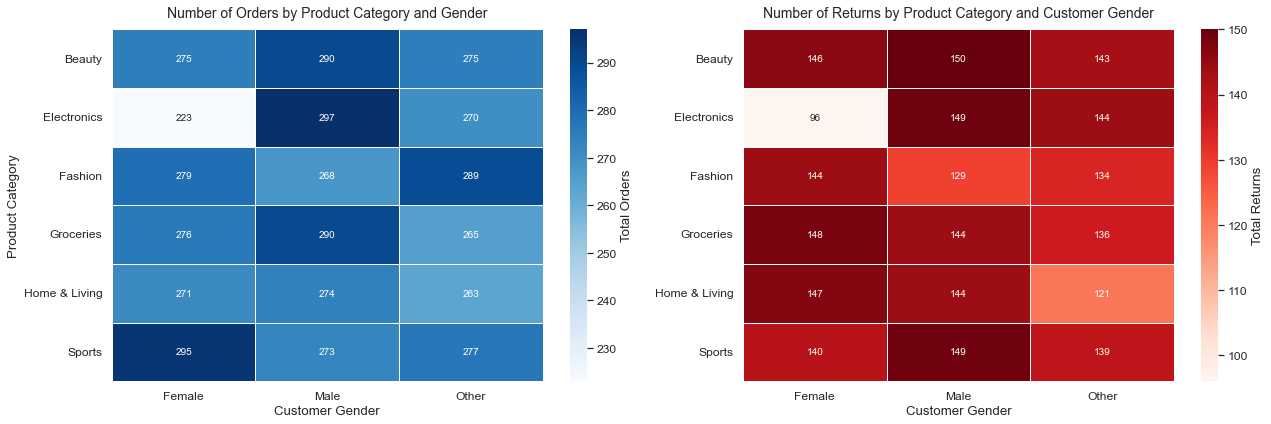

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#Number of Orders
sns.heatmap(
    order_counts,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Total Orders'},
    ax=axes[0]
)
axes[0].set_title("Number of Orders by Product Category and Gender", fontsize=14, pad=12)
axes[0].set_xlabel("Customer Gender")
axes[0].set_ylabel("Product Category")

#Number of Returns
sns.heatmap(
    return_counts,
    annot=True,
    fmt=".0f",
    cmap="Reds",   # red = many returns
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Total Returns'},
    ax=axes[1]
)
axes[1].set_title("Number of Returns by Product Category and Customer Gender", fontsize=14, pad=12)
axes[1].set_xlabel("Customer Gender")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

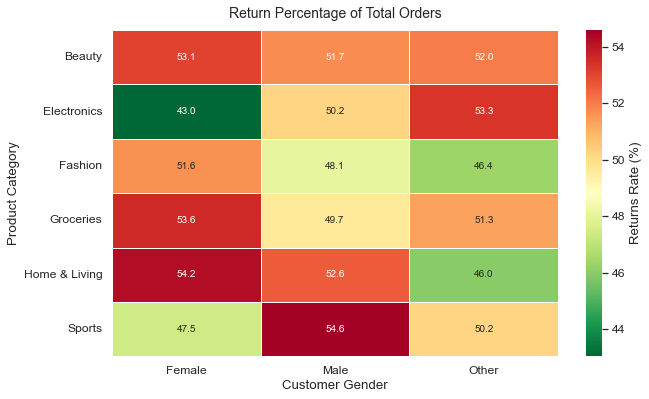

In [7]:
#return percetage
plt.figure(figsize=(10, 6))
sns.heatmap(
    return_percentage * 100,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",      # red = high return rate
    linewidths=0.5,
    linecolor="white",
    cbar_kws={'label': 'Returns Rate (%)'}
)
plt.title("Return Percentage of Total Orders", fontsize=14, pad=12)
plt.xlabel("Customer Gender")
plt.ylabel("Product Category")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

<ipython-input-8-7cc9a05aea59>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='returned', y='delivery_time_days', data=df, palette='Set2')


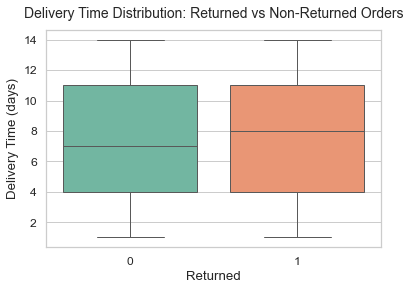

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,2447.0,7.423376,4.026353,1.0,4.0,7.0,11.0,14.0
1,2503.0,7.506592,4.038961,1.0,4.0,8.0,11.0,14.0


In [8]:
# Delivery time distribution by return status
sns.boxplot(x='returned', y='delivery_time_days', data=df, palette='Set2')
plt.title('Delivery Time Distribution: Returned vs Non-Returned Orders', fontsize=14, pad=12)
plt.xlabel('Returned')
plt.ylabel('Delivery Time (days)')
plt.show()

# Optional: quick numeric summary
df.groupby('returned')['delivery_time_days'].describe()


<ipython-input-9-c6085d36a624>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='returned', y='customer_rating', data=df, palette='Set1')


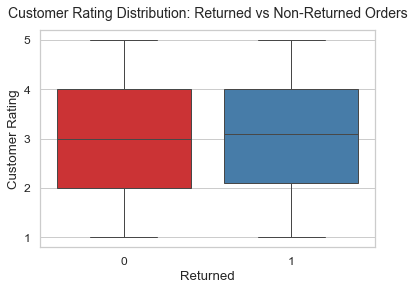

returned
0    2.977278
1    3.049820
Name: customer_rating, dtype: float64

In [9]:
# Customer ratings grouped by return status
sns.boxplot(x='returned', y='customer_rating', data=df, palette='Set1')
plt.title('Customer Rating Distribution: Returned vs Non-Returned Orders', fontsize=14, pad=12)
plt.xlabel('Returned')
plt.ylabel('Customer Rating')
plt.show()

# Optional: average rating per group
df.groupby('returned')['customer_rating'].mean()

In [10]:
df.groupby(['product_category', 'returned'])['customer_rating'].mean().unstack()


returned,0,1
product_category,,
Beauty,2.939401,3.078360
Electronics,2.992020,3.028792
Fashion,2.993939,3.096560
Groceries,2.955831,3.043224
Home & Living,2.950253,3.005583
Sports,3.028777,3.044393


<ipython-input-11-6c6f90d1b121>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='returned', y='order_value_usd', data=df, palette='pastel')


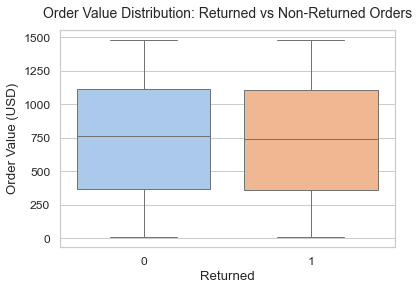

,count,mean,std,min,25%,50%,75%,max
returned,,,,,,,,
0,2447.0,743.653723,424.886520,5.66,366.395,760.58,1111.36,1480.86
1,2503.0,740.759281,427.200213,5.57,361.100,738.84,1102.95,1481.60


In [11]:
# Order value distribution by return status
sns.boxplot(x='returned', y='order_value_usd', data=df, palette='pastel')
plt.title('Order Value Distribution: Returned vs Non-Returned Orders', fontsize=14, pad=12)
plt.xlabel('Returned')
plt.ylabel('Order Value (USD)')
plt.show()

# Optional: summary statistics
df.groupby('returned')['order_value_usd'].describe()

<ipython-input-12-4bb382c57949>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


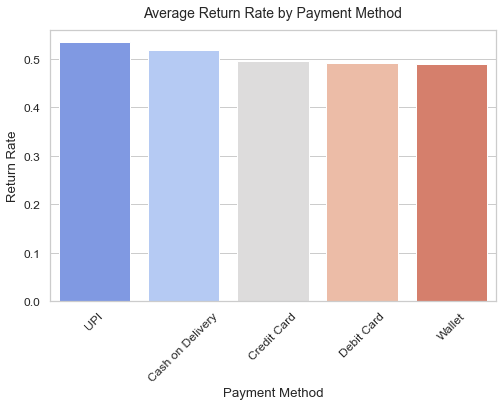

,Payment Method,Average Return Rate
0,UPI,0.533790
1,Cash on Delivery,0.519190
2,Credit Card,0.495010
3,Debit Card,0.490891
4,Wallet,0.489510


In [12]:
# Average return rate by payment method
returns_by_payment = (
    df.groupby('payment_method')['returned']
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(
    x=returns_by_payment.index,
    y=returns_by_payment.values,
    palette='coolwarm'
)
plt.title('Average Return Rate by Payment Method', fontsize=14, pad=12)
plt.ylabel('Return Rate')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.show()

returns_by_payment_df = returns_by_payment.reset_index()
returns_by_payment_df.columns = ['Payment Method', 'Average Return Rate']
display(returns_by_payment_df)

<ipython-input-13-3b92bd7b7c64>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


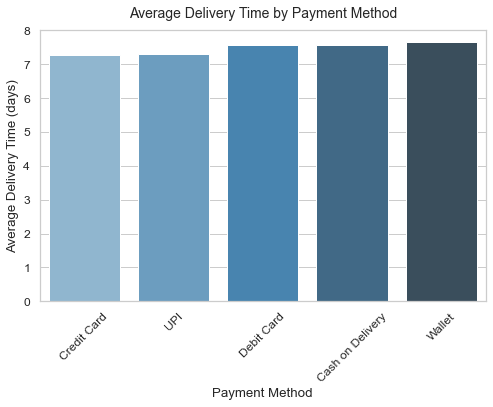

In [13]:
# Average delivery time by payment method
delivery_by_payment = (
    df.groupby('payment_method')['delivery_time_days']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,5))
sns.barplot(
    x=delivery_by_payment.index,
    y=delivery_by_payment.values,
    palette='Blues_d'
)
plt.title('Average Delivery Time by Payment Method', fontsize=14, pad=12)
plt.ylabel('Average Delivery Time (days)')
plt.xlabel('Payment Method')
plt.xticks(rotation=45)
plt.show()

In [14]:
# Calculate both average delivery time and return rate per payment method
payment_summary = (
    df.groupby('payment_method')
    .agg({
        'delivery_time_days': 'mean',
        'returned': 'mean'
    })
    .reset_index()
)

# Convert return rate to percentage
payment_summary['returned'] = payment_summary['returned'] * 100
payment_summary = payment_summary.rename(columns={
    'delivery_time_days': 'Avg Delivery Time (days)',
    'returned': 'Return Rate (%)'
})

display(payment_summary)


,payment_method,Avg Delivery Time (days),Return Rate (%)
0,Cash on Delivery,7.567164,51.918977
1,Credit Card,7.279441,49.500998
2,Debit Card,7.559717,49.089069
3,UPI,7.297747,53.379040
4,Wallet,7.634366,48.951049


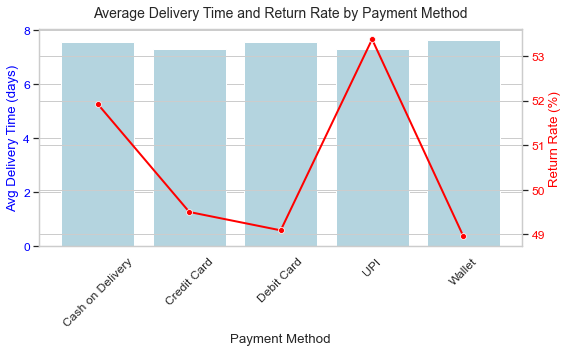

In [15]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Left axis - Average delivery time
sns.barplot(
    data=payment_summary,
    x='payment_method',
    y='Avg Delivery Time (days)',
    color='lightblue',
    ax=ax1
)
ax1.set_ylabel('Avg Delivery Time (days)', color='blue')
ax1.set_xlabel('Payment Method')
ax1.tick_params(axis='y', labelcolor='blue')
plt.xticks(rotation=45)

# Right axis - Return rate (%)
ax2 = ax1.twinx()
sns.lineplot(
    data=payment_summary,
    x='payment_method',
    y='Return Rate (%)',
    color='red',
    marker='o',
    linewidth=2,
    ax=ax2
)
ax2.set_ylabel('Return Rate (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Average Delivery Time and Return Rate by Payment Method', fontsize=14, pad=12)
plt.tight_layout()
plt.show()


In [16]:
#predictive model
# Feature selection
features = [
    'customer_age', 'customer_gender', 'product_category', 'payment_method',
    'order_value_usd', 'delivery_time_days', 'customer_rating'
]
target = 'returned'

X = df[features]
y = df[target]

In [17]:
#encode categorical variables
X = pd.get_dummies(X, drop_first=True)
X.head()

,customer_age,order_value_usd,delivery_time_days,customer_rating,customer_gender_Male,customer_gender_Other,product_category_Electronics,product_category_Fashion,product_category_Groceries,product_category_Home & Living,product_category_Sports,payment_method_Credit Card,payment_method_Debit Card,payment_method_UPI,payment_method_Wallet
0,37,1366.60,10,2.3,False,True,False,False,False,True,False,False,False,False,True
1,41,1175.89,6,1.8,False,False,False,True,False,False,False,False,False,False,False
2,30,1283.97,7,3.2,False,True,False,False,False,False,True,False,True,False,False
3,58,1245.76,14,3.8,False,False,True,False,False,False,False,True,False,False,False
4,59,1411.06,7,3.2,False,True,False,True,False,False,False,False,False,False,False


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=5
)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score

for depth in [3, 5, 7, 9, 12]:
    model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=depth)
    model.fit(X_train, y_train)
    acc_train = model.score(X_train, y_train)
    acc_test = model.score(X_test, y_test)
    print(f"Depth {depth}: train={acc_train:.3f}, test={acc_test:.3f}")


Depth 3: train=0.570, test=0.519
Depth 5: train=0.666, test=0.513
Depth 7: train=0.793, test=0.517
Depth 9: train=0.913, test=0.506
Depth 12: train=0.991, test=0.503


In [22]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.51      0.40      0.45       489
           1       0.52      0.62      0.56       501

    accuracy                           0.51       990
   macro avg       0.51      0.51      0.51       990
weighted avg       0.51      0.51      0.51       990


Confusion Matrix:
[[197 292]
 [190 311]]


<ipython-input-23-fb96e2568949>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[:10], y=importances.index[:10], palette='viridis')


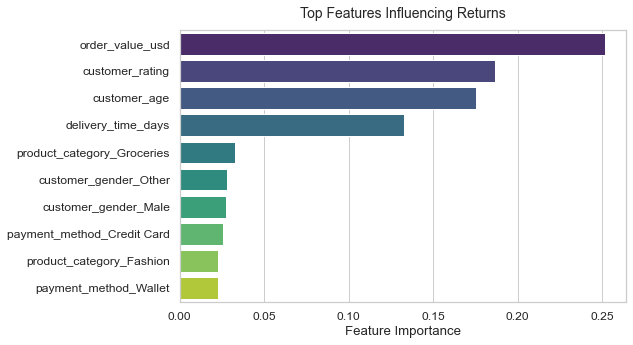

In [23]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances[:10], y=importances.index[:10], palette='viridis')
plt.title('Top Features Influencing Returns', fontsize=14, pad=12)
plt.xlabel('Feature Importance')
plt.ylabel('')
plt.show()